Flores do Brasil:

Analise em duas partes:

- **EDA** — distribuicao por especie, estado e linha do tempo de registros  
- **Clustering K-Means** — agrupamento geografico das ocorrencias, com selecao automatica do K via Silhouette Score

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings("ignore")

In [16]:
# Cores extraidas das CSS variables do portfolio (dark theme)
PORTFOLIO = {
    "bg":      "#071a0e",
    "bg2":     "#0c2214",
    "card":    "#0f2918",
    "border":  "#2a6642",
    "accent":  "#5ecf8a",
    "accent2": "#3aad6a",
    "accent3": "#a8edca",
    "text":    "#d6f5e3",
    "muted":   "#7bbf9a",
    "link":    "#7de8ac",
}

# Paleta sequencial para graficos
PALETA = [
    "#5ecf8a",  # verde
    "#4db6ac",  # teal
    "#64b5f6",  # azul
    "#9575cd",  # roxo
    "#ffb74d",  # laranja
    "#ef5350",  # vermelho
    "#ec407a",  # rosa
    "#c0ca33",  # lima
    "#26a69a",  # turquesa
    "#8d6e63",  # marrom
]

plt.rcParams.update({
    "figure.facecolor":  PORTFOLIO["bg"],
    "axes.facecolor":    PORTFOLIO["bg2"],
    "axes.edgecolor":    PORTFOLIO["border"],
    "axes.labelcolor":   PORTFOLIO["text"],
    "xtick.color":       PORTFOLIO["muted"],
    "ytick.color":       PORTFOLIO["muted"],
    "text.color":        PORTFOLIO["text"],
    "grid.color":        PORTFOLIO["border"],
    "grid.linestyle":    "--",
    "grid.alpha":        0.4,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.facecolor":  PORTFOLIO["card"],
    "legend.edgecolor":  PORTFOLIO["border"],
    "legend.labelcolor": PORTFOLIO["text"],
})

PASTA_GRAFICOS = "graficos"
os.makedirs(PASTA_GRAFICOS, exist_ok=True)

### 1. Carregamento dos Dados

Leitura do parquet gerado na Etapa 1

In [17]:
df = pd.read_parquet("dados/flores_brasil.parquet")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")
df.head()

Shape: 5,493 linhas x 12 colunas
Colunas: ['especie', 'familia', 'genero', 'latitude', 'longitude', 'estado', 'municipio', 'ano', 'mes', 'tipo_registro', 'dataset', 'id_gbif']


,especie,familia,genero,latitude,longitude,estado,municipio,ano,mes,tipo_registro,dataset,id_gbif
0,Zeyheria Tuberculosa,Bignoniaceae,Zeyheria,-22.887250,-48.490417,São Paulo,Botucatu,2026,1,PRESERVED_SPECIMEN,NaN,3414152432
1,Mauritia Flexuosa,Arecaceae,Mauritia,-2.704655,-42.872883,Maranhão,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938027332
2,Godartiana Muscosa,Nymphalidae,Godartiana,-20.522878,-41.861437,Minas Gerais,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938027564
3,Sarcoramphus Papa,Cathartidae,Sarcoramphus,-26.306104,-49.155540,Santa Catarina,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938027691
4,Tyrannus Melancholicus,Tyrannidae,Tyrannus,-15.737629,-47.864714,Distrito Federal,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938028534


In [18]:
# Visao rapida de nulos e tipos
print("Tipos e nulos por coluna:\n")
info = pd.DataFrame({
    "dtype":  df.dtypes,
    "nulos":  df.isnull().sum(),
    "% nulo": (df.isnull().mean() * 100).round(1),
})
print(info.to_string())

Tipos e nulos por coluna:

                 dtype  nulos  % nulo
especie            str      0     0.0
familia            str      1     0.0
genero             str      0     0.0
latitude       float64      0     0.0
longitude      float64      0     0.0
estado             str      0     0.0
municipio          str   5483    99.8
ano              Int64      0     0.0
mes              Int64      0     0.0
tipo_registro      str      0     0.0
dataset            str     40     0.7
id_gbif            str      0     0.0


### 2. Analise Exploratoria (EDA)

Tres perspectivas sobre o dataset:

1. Quais especies aparecem mais?
2. Como os registros se distribuem por estado?
3. Como a quantidade de registros evoluiu ao longo do tempo?

**2.1** Top 10 Especies Mais Registradas

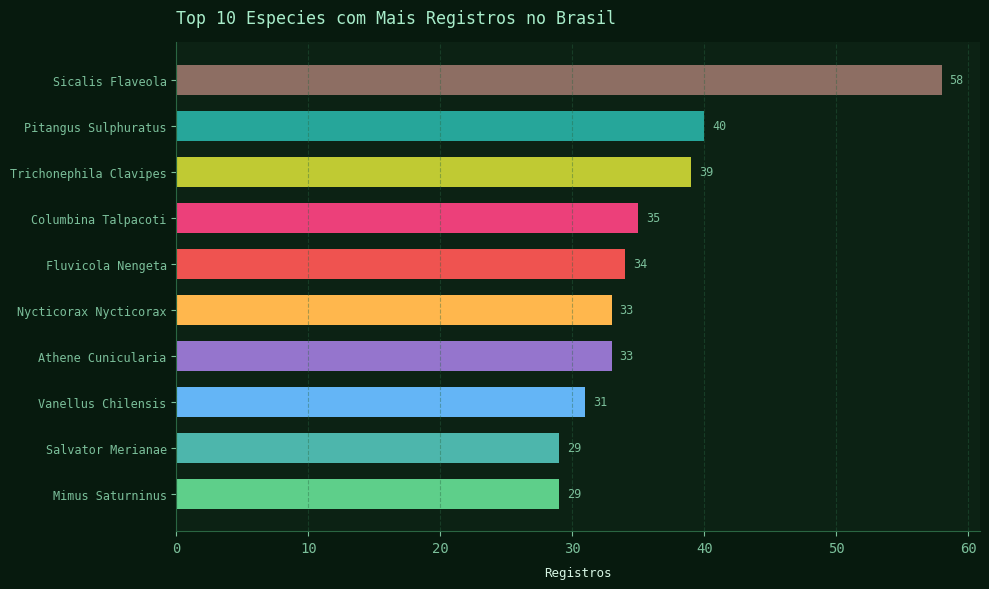

Salvo: 01_top_especies.png


In [19]:
top10 = df["especie"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10.index, top10.values, color=PALETA[:10], edgecolor="none", height=0.65)

for bar, val in zip(bars, top10.values):
    ax.text(
        val + max(top10.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=8.5, color=PORTFOLIO["muted"]
    )

ax.set_title("Top 10 Especies com Mais Registros no Brasil",
             fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left")
ax.set_xlabel("Registros", fontsize=9, labelpad=8)
ax.tick_params(axis="y", labelsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x")

plt.tight_layout()
plt.savefig(f"{PASTA_GRAFICOS}/01_top_especies.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 01_top_especies.png")

**2.2** Distribuicao por Estado

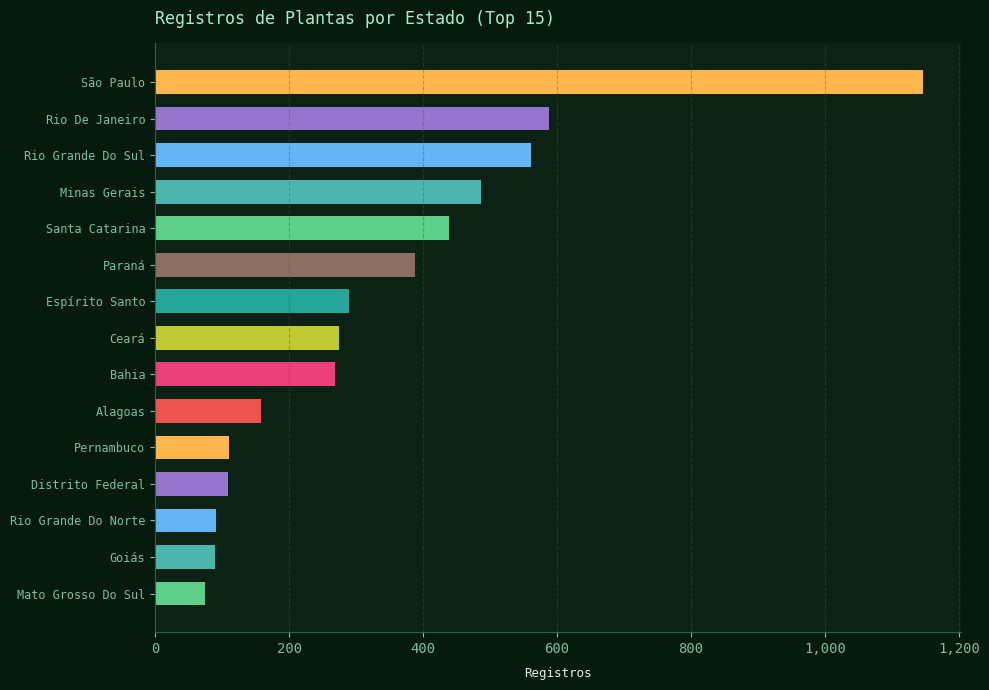

Salvo: 02_registros_por_estado.png


In [20]:
if "estado" not in df.columns:
    print("Coluna 'estado' nao encontrada.")
else:
    por_estado = (
        df["estado"]
        .value_counts()
        .dropna()
        .head(15)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    cores = [PALETA[i % len(PALETA)] for i in range(len(por_estado))]
    ax.barh(por_estado.index, por_estado.values, color=cores, edgecolor="none", height=0.65)

    ax.set_title("Registros de Plantas por Estado (Top 15)",
                 fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left")
    ax.set_xlabel("Registros", fontsize=9, labelpad=8)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x")

    plt.tight_layout()
    plt.savefig(f"{PASTA_GRAFICOS}/02_registros_por_estado.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo: 02_registros_por_estado.png")

**2.3** Serie Temporal de Registros

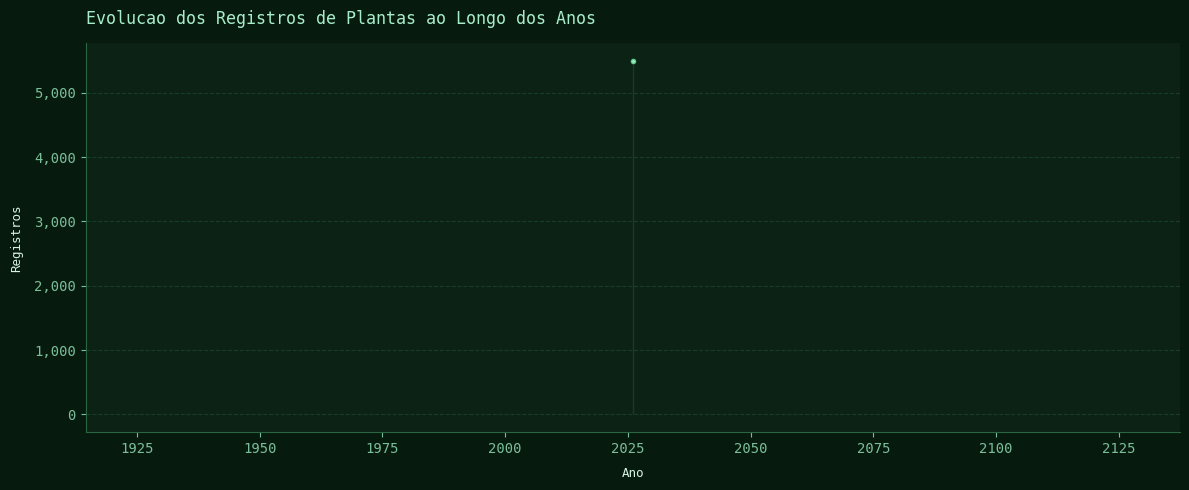

Salvo: 03_serie_temporal.png


In [21]:
if "ano" not in df.columns:
    print("Coluna 'ano' nao encontrada.")
else:
    por_ano = (
        df[df["ano"] >= 1950]["ano"]
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        por_ano.index.astype(int), por_ano.values,
        color=PORTFOLIO["accent"], linewidth=2,
        marker="o", markersize=3, markerfacecolor=PORTFOLIO["accent3"]
    )
    ax.fill_between(
        por_ano.index.astype(int), por_ano.values,
        alpha=0.15, color=PORTFOLIO["accent"]
    )

    ax.set_title("Evolucao dos Registros de Plantas ao Longo dos Anos",
                 fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left")
    ax.set_xlabel("Ano", fontsize=9, labelpad=8)
    ax.set_ylabel("Registros", fontsize=9, labelpad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y")

    plt.tight_layout()
    plt.savefig(f"{PASTA_GRAFICOS}/03_serie_temporal.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo: 03_serie_temporal.png")

### 3. Clustering K-Means

O objetivo e agrupar as ocorrencias por coordenada geografica, identificando regioes
com perfis similares de biodiversidade sem rotulos pre-definidos.

**Features:** `latitude` e `longitude` normalizadas com `StandardScaler`  
**K ideal:** selecionado automaticamente pelo maior Silhouette Score

**3.1** Preparacao das Features

In [9]:
df_geo = df.dropna(subset=["latitude", "longitude"]).copy()
print(f"Registros com coordenadas validas: {len(df_geo):,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_geo[["latitude", "longitude"]])
print(f"Shape apos normalizacao: {X_scaled.shape}")

Registros com coordenadas validas: 5,493
Shape apos normalizacao: (5493, 2)


**3.2** Selecao do K — Metodo do Cotovelo e Silhouette Score

Dois criterios avaliados em conjunto:

- **Inercia (cotovelo):** queda na variancia intra-cluster
- **Silhouette Score:** mede a separacao entre clusters (0–1, quanto maior melhor). Usado como criterio de decisao automatica.

In [10]:
K_MIN, K_MAX = 2, 8

inercias     = []
silhouettes  = []
ks           = range(K_MIN, K_MAX + 1)

print(f"Testando K de {K_MIN} a {K_MAX}...\n")
print(f"{'K':>3}  {'Inercia':>12}  {'Silhouette':>12}")
print("-" * 32)

for k in ks:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    inercias.append(km.inertia_)
    silhouettes.append(sil)
    print(f"{k:>3}  {km.inertia_:>12,.0f}  {sil:>12.4f}")

k_ideal = list(ks)[silhouettes.index(max(silhouettes))]
print(f"\nK ideal (Silhouette Score maximo): {k_ideal}")

Testando K de 2 a 8...

  K       Inercia    Silhouette
--------------------------------
  2         5,401        0.5720
  3         3,587        0.4722
  4         2,046        0.5115
  5         1,650        0.4587
  6         1,365        0.5006
  7         1,154        0.4852
  8           948        0.4771

K ideal (Silhouette Score maximo): 2


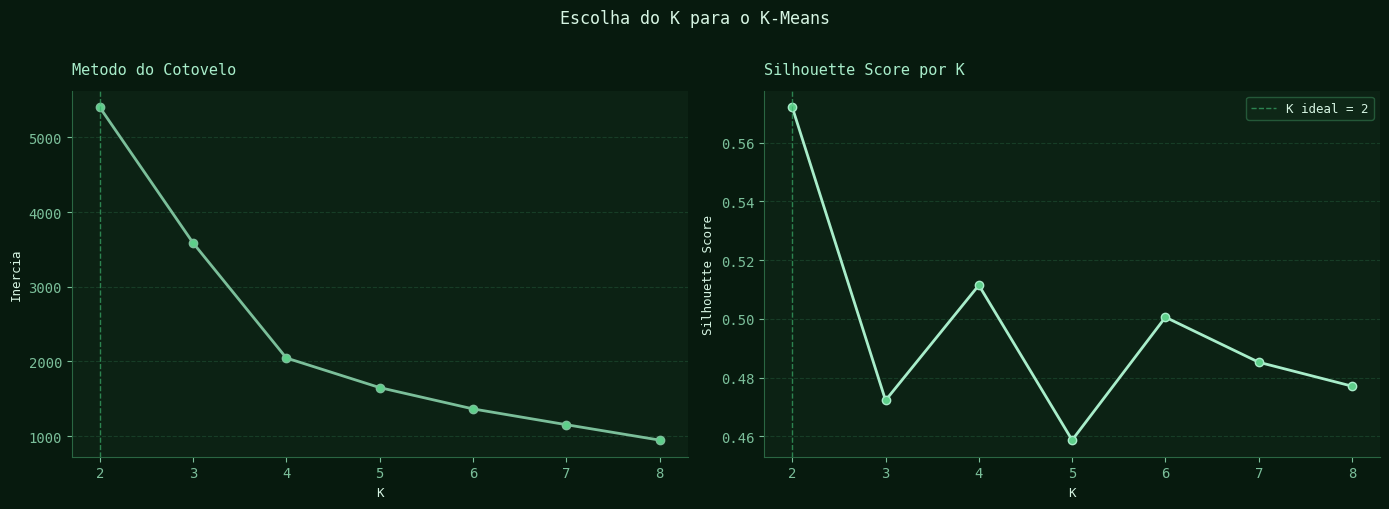

Salvo: 04_elbow_silhouette.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cotovelo
ax1.plot(list(ks), inercias,
         color=PORTFOLIO["muted"], linewidth=2,
         marker="o", markersize=6, markerfacecolor=PORTFOLIO["accent"])
ax1.axvline(k_ideal, color=PORTFOLIO["accent2"], linestyle="--", linewidth=1, alpha=0.7)
ax1.set_title("Metodo do Cotovelo",
              fontsize=11, pad=12, color=PORTFOLIO["accent3"], loc="left")
ax1.set_xlabel("K", fontsize=9)
ax1.set_ylabel("Inercia", fontsize=9)
ax1.grid(axis="y")

# Silhouette
ax2.plot(list(ks), silhouettes,
         color=PORTFOLIO["accent3"], linewidth=2,
         marker="o", markersize=6, markerfacecolor=PORTFOLIO["accent"])
ax2.axvline(k_ideal, color=PORTFOLIO["accent2"], linestyle="--", linewidth=1, alpha=0.7,
            label=f"K ideal = {k_ideal}")
ax2.set_title("Silhouette Score por K",
              fontsize=11, pad=12, color=PORTFOLIO["accent3"], loc="left")
ax2.set_xlabel("K", fontsize=9)
ax2.set_ylabel("Silhouette Score", fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(axis="y")

fig.suptitle("Escolha do K para o K-Means",
             fontsize=12, color=PORTFOLIO["text"], y=1.01)

plt.tight_layout()
plt.savefig(f"{PASTA_GRAFICOS}/04_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 04_elbow_silhouette.png")

**3.3** Treinamento com K Ideal

In [12]:
km_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
labels   = km_final.fit_predict(X_scaled)

df_geo = df_geo.copy()
df_geo["cluster"] = labels.astype(str)

print(f"K-Means treinado com K = {k_ideal}")
print("\nDistribuicao dos clusters:")
print(df_geo["cluster"].value_counts().sort_index().to_string())

K-Means treinado com K = 2

Distribuicao dos clusters:
cluster
0    4385
1    1108


**3.4** Visualizacao Geografica dos Clusters

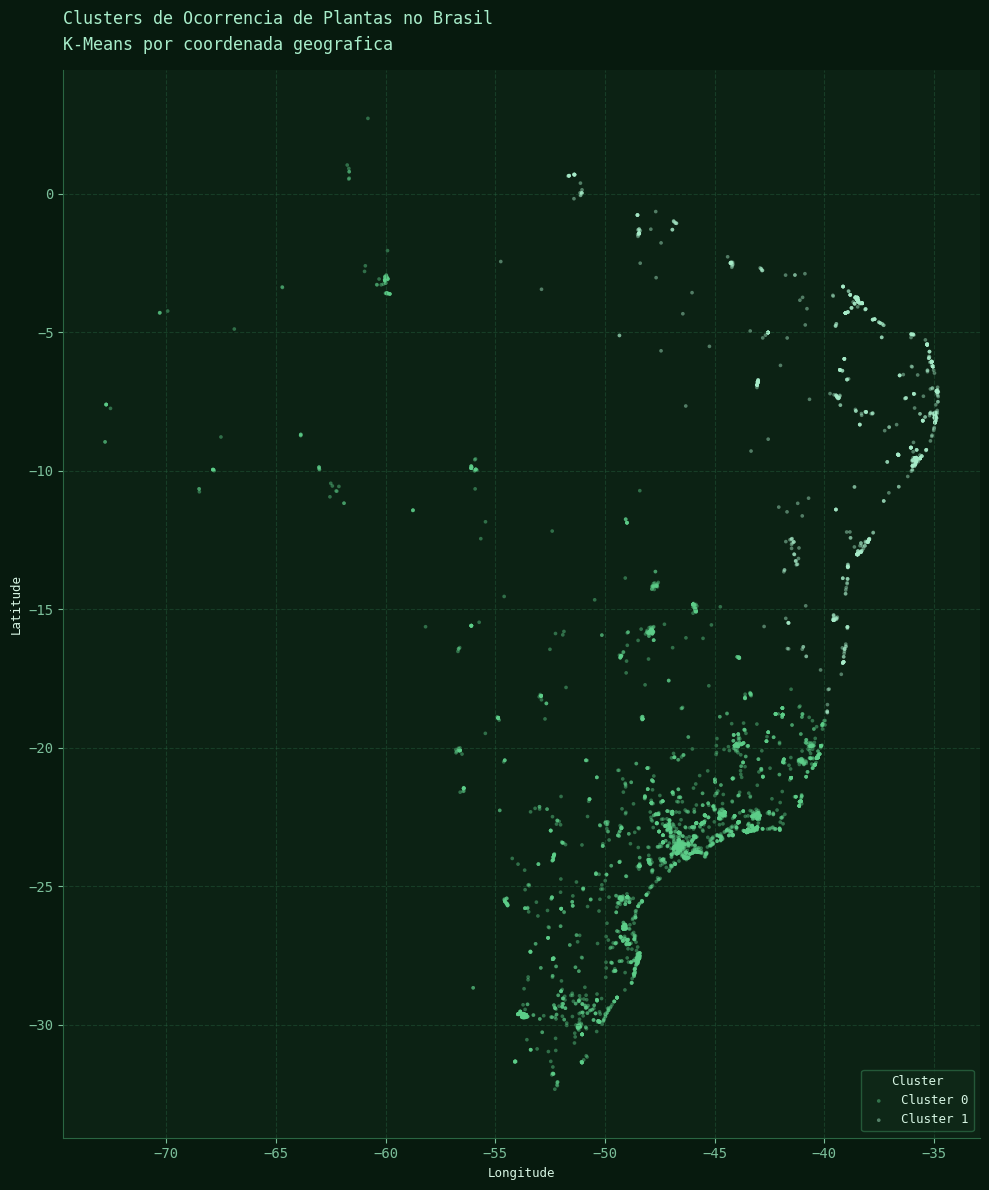

Salvo: 05_clusters_mapa.png


In [13]:
cores_cluster = {str(i): PALETA[i % len(PALETA)] for i in range(k_ideal)}

fig, ax = plt.subplots(figsize=(10, 12))

for cluster_id, grupo in df_geo.groupby("cluster"):
    ax.scatter(
        grupo["longitude"], grupo["latitude"],
        c=cores_cluster[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.45, s=7, edgecolors="none"
    )

ax.set_title(
    "Clusters de Ocorrencia de Plantas no Brasil\nK-Means por coordenada geografica",
    fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left", linespacing=1.6
)
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.legend(title="Cluster", loc="lower right", fontsize=9, title_fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig(f"{PASTA_GRAFICOS}/05_clusters_mapa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 05_clusters_mapa.png")

**3.5** Resumo por Cluster

Estatisticas agregadas por cluster: total de registros, especies unicas,
especie mais frequente, centroide geografico e estado com mais ocorrencias.

In [14]:
resumo = df_geo.groupby("cluster").agg(
    total_registros = ("especie", "count"),
    especies_unicas = ("especie", "nunique"),
    especie_top     = ("especie", lambda x: x.value_counts().idxmax()),
    lat_media       = ("latitude",  "mean"),
    lon_media       = ("longitude", "mean"),
).round(3)

if "estado" in df_geo.columns:
    estado_top = df_geo.groupby("cluster")["estado"].agg(
        lambda x: x.value_counts().idxmax() if x.notna().any() else "N/A"
    )
    resumo["estado_top"] = estado_top

resumo.to_csv(f"{PASTA_GRAFICOS}/resumo_clusters.csv")
print("Salvo: resumo_clusters.csv\n")
resumo

Salvo: resumo_clusters.csv



,total_registros,especies_unicas,especie_top,lat_media,lon_media,estado_top
cluster,,,,,,
0,4385,1780,Sicalis Flaveola,-22.934,-47.742,São Paulo
1,1108,610,Canistrum Camacaense,-7.741,-38.829,Ceará


### 4. Conclusao

Os clusters revelam agrupamentos geograficos coerentes com as regioes de biodiversidade 
do Brasil — concentracoes no Cerrado, Mata Atlantica, Amazonia e litoral nordestino
tendem a emergir como grupos distintos dependendo do dataset coletado.